# Photo-to-Product Search: Multi-Modal Embeddings with Jina CLIP v2 on EIS

## Install Prerequisites

In [53]:
! pip install -q -U -r requirements.txt

## Create Environment

In [2]:
%%bash
terraform -chdir=terraform init  -upgrade
terraform -chdir=terraform apply -auto-approve

Initializing the backend...
Initializing provider plugins...
- Finding elastic/ec versions matching "~> 0.12"...
- Finding elastic/elasticstack versions matching "~> 0.14"...
- Using previously-installed elastic/ec v0.12.4
- Using previously-installed elastic/elasticstack v0.14.3

Terraform has been successfully initialized!

You may now begin working with Terraform. Try running "terraform plan" to see
any changes that are required for your infrastructure. All Terraform commands
should now work.

If you ever set or change modules or backend configuration for Terraform,
rerun this command to reinitialize your working directory. If you forget, other
commands will detect it and remind you to do so if necessary.

Terraform used the selected providers to generate the following execution
plan. Resource actions are indicated with the following symbols:
  + create

Terraform will perform the following actions:

  # ec_elasticsearch_project.demo_project will be created
  + resource "ec_elastics

## Create Environment File

In [3]:
%%bash
cat > .env << EOF
ELASTIC_USERNAME=$(terraform -chdir=terraform output -raw elastic_username)
ELASTIC_PASSWORD=$(terraform -chdir=terraform output -raw elastic_password)
ELASTIC_CLOUD_ID=$(terraform -chdir=terraform output -raw elastic_cloud_id)
EOF

## Fetch Hardware Store Images

In [60]:
import csv
import time
import requests
from pathlib import Path
from urllib.parse import unquote

# Curated catalog: category → list of direct Wikimedia Commons image URLs
CATALOG = {
    "Hex bolt": [
        "https://upload.wikimedia.org/wikipedia/commons/a/a6/Bolt.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/3/36/Bolts.jpg",
    ],
    "Carriage bolt": [
        "https://upload.wikimedia.org/wikipedia/commons/d/d4/AFS_-_fasteners_picture.JPG",
        "https://upload.wikimedia.org/wikipedia/commons/5/59/Bolds_in_the_box.jpg",
    ],
    "Lag screw": [
        "https://upload.wikimedia.org/wikipedia/commons/c/cb/Din_571.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/7/7a/Lag_screw.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/e/ea/Fetter-thread_lag_screw_with_full_point.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a5/Lag_bolt_screw_-_Din_571_%28edited%29.png",
    ],
    "Eye bolt": [
        "https://upload.wikimedia.org/wikipedia/commons/7/71/Eye_bolt.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/4/49/Eyebolt.jpg",
    ],
    "Phillips screw": [
        "https://upload.wikimedia.org/wikipedia/commons/0/0c/Phillips_screw.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/b/b8/Screw.jpg",
    ],
    "Flat head screw": [
        "https://upload.wikimedia.org/wikipedia/commons/a/a4/A_screw_01.JPG",
        "https://upload.wikimedia.org/wikipedia/commons/6/6f/An_old_and_rusted_screw_%28original%29.jpg",
    ],
    "Hex nut": [
        "https://upload.wikimedia.org/wikipedia/commons/8/8f/Bolt_and_Nut_2018.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a2/Bolt_nut.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/3/3f/Nuts_and_bolts.jpg",
    ],
    "Wing nut": [
        "https://upload.wikimedia.org/wikipedia/commons/d/df/Wingnut.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/3/30/Wing_nuts.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/1/1c/Wingnuts.jpg",
    ],
    "Drywall anchor": [
        "https://upload.wikimedia.org/wikipedia/commons/1/1e/6er_Spreizd%C3%BCbel1647.JPG",
    ],
}

STORE_LAYOUT = {
    "Hex bolt":        {"type": "Bolt",   "aisle": 3, "bin": "A12"},
    "Carriage bolt":   {"type": "Bolt",   "aisle": 3, "bin": "B04"},
    "Lag screw":       {"type": "Screw",  "aisle": 4, "bin": "A01"},
    "Eye bolt":        {"type": "Bolt",   "aisle": 3, "bin": "C07"},
    "Phillips screw":  {"type": "Screw",  "aisle": 4, "bin": "B15"},
    "Flat head screw": {"type": "Screw",  "aisle": 4, "bin": "B22"},
    "Hex nut":         {"type": "Nut",    "aisle": 5, "bin": "A03"},
    "Wing nut":        {"type": "Nut",    "aisle": 5, "bin": "A09"},
    "Drywall anchor":  {"type": "Anchor", "aisle": 6, "bin": "A18"},
}

DESCRIPTIONS = {
    "Hex bolt":        "Six-sided head bolt for heavy-duty fastening with a nut",
    "Carriage bolt":   "Round-head bolt with square neck to prevent rotation",
    "Lag screw":       "Heavy hex-head screw for wood-to-wood or wood-to-masonry",
    "Eye bolt":        "Bolt with a looped head for attaching cables or ropes",
    "Phillips screw":  "Cross-head screw for general purpose fastening",
    "Flat head screw": "Countersunk screw that sits flush with the surface",
    "Hex nut":         "Six-sided nut used with a matching bolt",
    "Wing nut":        "Hand-tightenable nut with two wings for tool-free use",
    "Drywall anchor":  "Fastener that secures screws in drywall without a stud",
}

IMAGES_DIR = Path("images")
if IMAGES_DIR.exists() and any(IMAGES_DIR.iterdir()) and Path("metadata.csv").exists():
    print(f"Images already present ({sum(1 for _ in IMAGES_DIR.iterdir())} files). Skipping download.")
else:
    IMAGES_DIR.mkdir(exist_ok=True)
    HEADERS = {"User-Agent": "ClipV2HardwareDemo/1.0 (https://github.com/elastic)"}
    metadata_rows = []

    for category_name, urls in CATALOG.items():
        layout = STORE_LAYOUT[category_name]
        cat_slug = category_name.lower().replace(" ", "_")
        saved = 0
        for url in urls:
            raw_name = unquote(url.rsplit("/", 1)[-1])
            ext = raw_name.rsplit(".", 1)[-1].lower()
            if ext not in ("jpg", "jpeg", "png", "webp"):
                ext = "jpg"
            filename = f"{cat_slug}_{saved + 1}.{ext}"
            filepath = IMAGES_DIR / filename
            try:
                r = requests.get(url, timeout=20, headers=HEADERS)
                r.raise_for_status()
                filepath.write_bytes(r.content)
                metadata_rows.append({
                    "filename": filename, "name": category_name,
                    "type": layout["type"], "description": DESCRIPTIONS[category_name],
                    "aisle": layout["aisle"], "bin": layout["bin"],
                    "image_url": url,
                })
                saved += 1
            except Exception as e:
                print(f"  Warning: {url}: {e}")
            time.sleep(1)
        print(f"{category_name}: {saved} images")

    with open("metadata.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["filename", "name", "type", "description", "aisle", "bin", "image_url"])
        writer.writeheader()
        writer.writerows(metadata_rows)
    print(f"\nTotal: {len(metadata_rows)} images. Metadata written to metadata.csv")

Images already present (21 files). Skipping download.


## Connect to Elasticsearch

In [61]:
import os
from dotenv import load_dotenv
from elasticsearch import Elasticsearch

load_dotenv(override=True)

es = Elasticsearch(
    cloud_id=os.environ["ELASTIC_CLOUD_ID"],
    basic_auth=(os.environ["ELASTIC_USERNAME"], os.environ["ELASTIC_PASSWORD"]),
)

print(f"Connected to Elasticsearch")

Connected to Elasticsearch


## Create Hardware Index

In [75]:
INDEX = "hardware"

if es.indices.exists(index=INDEX):
    es.indices.delete(index=INDEX)
    print(f"Deleted existing index '{INDEX}'")

es.indices.create(
    index=INDEX,
    mappings={
        "properties": {
            "embedding":   {"type": "dense_vector", "dims": 1024, "index": True, "similarity": "cosine"},
            "name":        {"type": "text"},
            "type":        {"type": "text"},
            "description": {"type": "text"},
            "aisle":       {"type": "integer"},
            "bin":         {"type": "keyword"},
            "image_path":  {"type": "keyword", "index": False},
            "image_url":   {"type": "keyword", "index": False}
        }
    },
)
print(f"Index '{INDEX}' created")

Deleted existing index 'hardware'
Index 'hardware' created


## Index Images

In [76]:
import base64
import csv
from pathlib import Path
from elasticsearch.helpers import bulk
from tenacity import retry, retry_if_exception, stop_after_attempt, wait_exponential_jitter

def is_retryable(e):
    return hasattr(e, 'status_code') and e.status_code == 429

def image_to_base64(path: str) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

@retry(retry=retry_if_exception(is_retryable), stop=stop_after_attempt(6), wait=wait_exponential_jitter(initial=1, max=30), reraise=True)
def get_image_embedding(img_b64: str, mime: str = "image/jpg") -> list:
    resp = es.inference.inference(
        inference_id=".jina-clip-v2",
        body={"input_type": "INGEST","input": [{"content": {"type": "image", "format": "base64", "value": f"data:{mime};base64,{img_b64}"}}]},
    )
    return resp["embeddings"][0]["embedding"]

@retry(retry=retry_if_exception(is_retryable), stop=stop_after_attempt(6), wait=wait_exponential_jitter(initial=1, max=30), reraise=True)
def get_image_embedding_by_url(url: str) -> list:
    resp = es.inference.inference(
        inference_id=".jina-clip-v2",
        body={"input_type": "INGEST","input": [{"content": {"type": "image", "value": url}}]},
    )
    return resp["embeddings"][0]["embedding"]

@retry(retry=retry_if_exception(is_retryable), stop=stop_after_attempt(6), wait=wait_exponential_jitter(initial=1, max=30), reraise=True)
def get_text_embedding(text: str) -> list:
    resp = es.inference.inference(
        inference_id=".jina-clip-v2",
        body={"input_type": "INGEST","input": [{"content": {"type": "text", "value": text}}]},
    )
    return resp["embeddings"][0]["embedding"]

actions = []
with open("metadata.csv", newline="") as f:
    for row in csv.DictReader(f):
        img_path = Path("images") / row["filename"]
        if not img_path.exists():
            print(f"Skipping missing: {img_path}")
            continue
        ext = img_path.suffix.lower().lstrip(".")
        mime = "image/jpg" if ext in ("jpg", "jpeg") else f"image/{ext}"
        try:
            embedding = get_image_embedding(image_to_base64(str(img_path)), mime)
        except Exception as e:
            print(f"Error embedding {row['filename']}: {e}")
            continue
        actions.append({
            "_index": INDEX,
            "_source": {
                "embedding": embedding, "name": row["name"],
                "type": row["type"], "description": row["description"],
                "aisle": int(row["aisle"]), "bin": row["bin"],
                "image_path": str(img_path),
                "image_url": row["image_url"]
            },
        })
        print(f"  Embedded: {row['filename']}")

success, errors = bulk(es, actions)
es.indices.refresh(index=INDEX)
print(f"\nIndexed {success} documents, {len(errors)} errors")

  Embedded: hex_bolt_1.jpg
  Embedded: hex_bolt_2.jpg
  Embedded: carriage_bolt_1.jpg
  Embedded: carriage_bolt_2.jpg
  Embedded: lag_screw_1.jpg
  Embedded: lag_screw_2.jpg
  Embedded: lag_screw_3.jpg
  Embedded: lag_screw_4.png
  Embedded: eye_bolt_1.jpg
  Embedded: eye_bolt_2.jpg
  Embedded: phillips_screw_1.jpg
  Embedded: phillips_screw_2.jpg
  Embedded: flat_head_screw_1.jpg
  Embedded: flat_head_screw_2.jpg
  Embedded: hex_nut_1.jpg
  Embedded: hex_nut_2.jpg
  Embedded: hex_nut_3.jpg
  Embedded: wing_nut_1.jpg
  Embedded: wing_nut_2.jpg
  Embedded: wing_nut_3.jpg
  Embedded: drywall_anchor_1.jpg

Indexed 21 documents, 0 errors


## Image Search

Upload a photo of a fastener to find what it is and where it lives in the store.

Query image: images/wing_nut_1.jpg



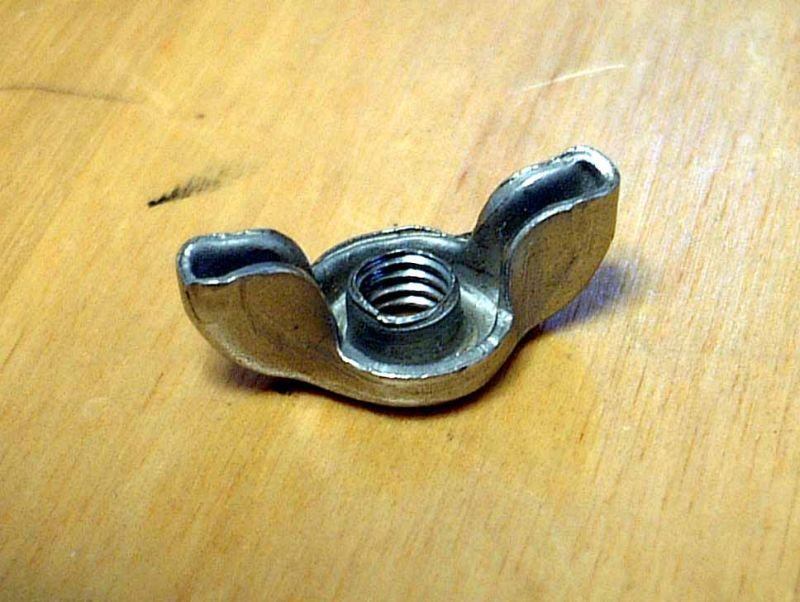
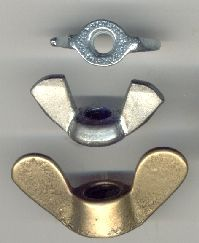
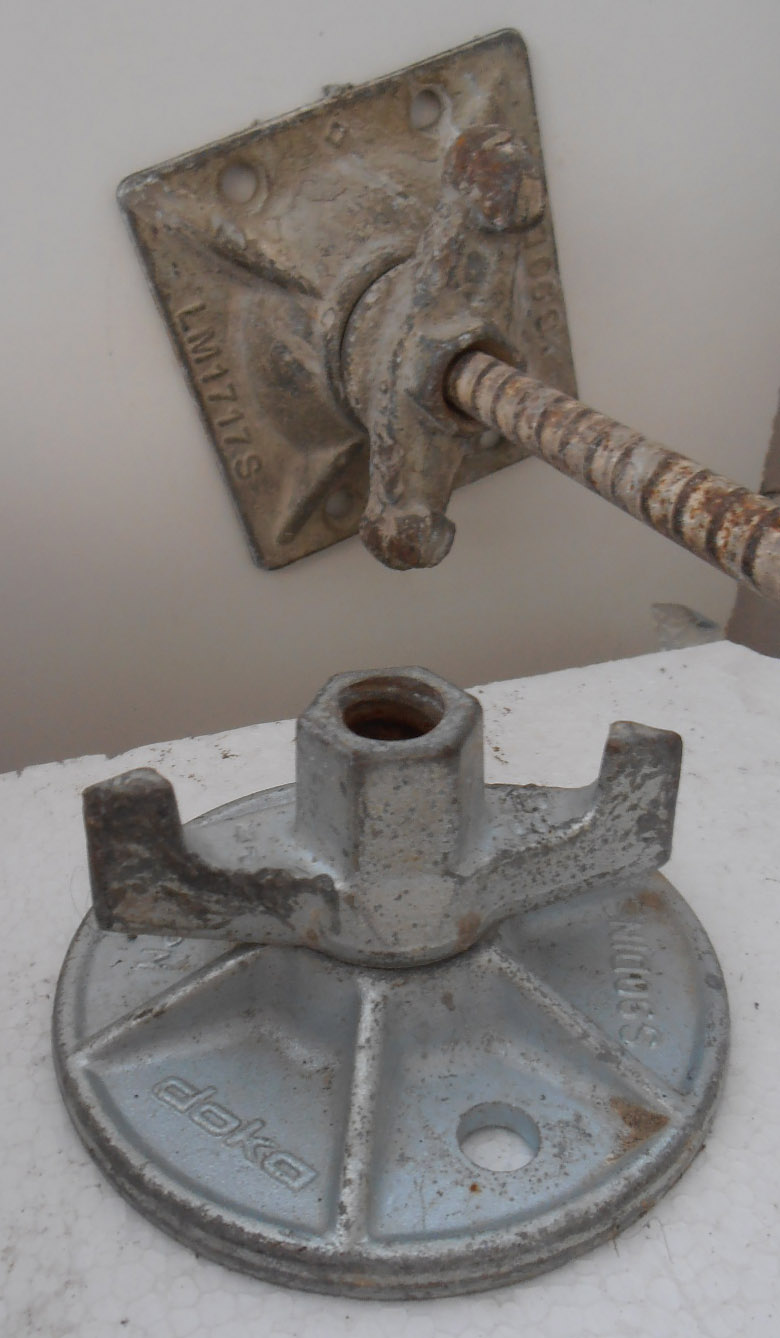

In [78]:
from IPython.display import display, HTML

# Replace query_image_path with any fastener photo you like
query_image_path = "images/wing_nut_1.jpg"
print(f"Query image: {query_image_path}")

ext = query_image_path.rsplit(".", 1)[-1].lower()
mime = "image/jpg" if ext in ("jpg", "jpeg") else f"image/{ext}"
embedding = get_image_embedding(image_to_base64(query_image_path), mime)

hits = es.search(
    index=INDEX,
    knn={"field": "embedding", "query_vector": embedding, "k": 3, "num_candidates": 20},
    source=["name", "description", "aisle", "bin", "image_path"],
)["hits"]["hits"]

cards = []
for hit in hits:
    s = hit["_source"]
    img_ext = s["image_path"].rsplit(".", 1)[-1].lower()
    img_mime = "image/jpg" if img_ext in ("jpg", "jpeg") else f"image/{img_ext}"
    img_b64 = image_to_base64(s["image_path"])
    cards.append(f"""
    <div style='display:inline-block;margin:10px;width:200px;font-family:sans-serif;vertical-align:top'>
      <img src='data:{img_mime};base64,{img_b64}'
           style='width:200px;height:150px;object-fit:cover;border-radius:6px;border:1px solid #ddd'/>
      <p style='margin:6px 0 2px'><b>{s['name']}</b></p>
      <p style='margin:2px 0;font-size:0.82em;color:#555'>{s['description']}</p>
      <p style='margin:4px 0;font-size:0.85em'>&#128205; Aisle {s['aisle']}, Bin {s['bin']}</p>
      <p style='margin:2px 0;font-size:0.78em;color:#999'>score: {hit['_score']:.4f}</p>
    </div>""")

display(HTML(f"<h4>Image Query Results</h4><div>{''.join(cards)}</div>"))

## Text Search

Cross-modal search: a plain-English description retrieves matching images via the shared CLIP embedding space.

Query: 'eye bolt'




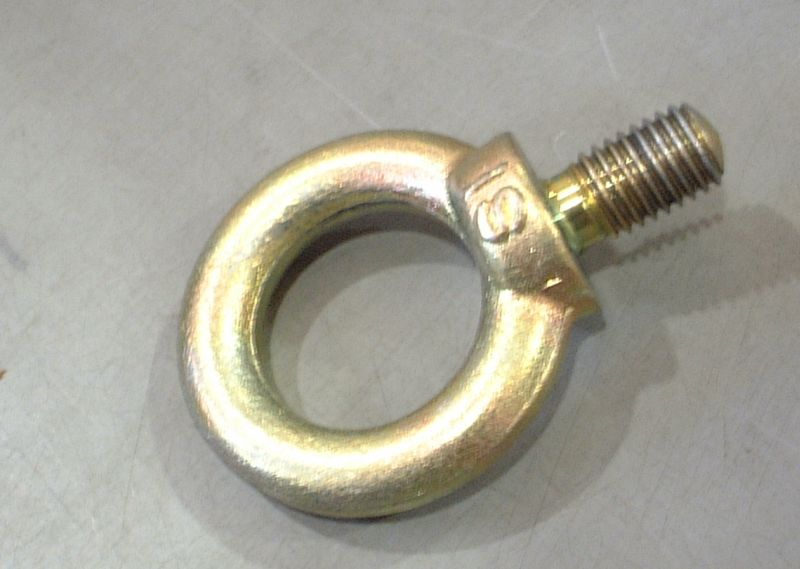
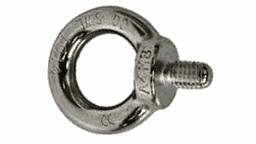

In [80]:
query_text = "eye bolt" 
print(f"Query: '{query_text}'\n")

embedding = get_text_embedding(query_text)

hits = es.search(
    index=INDEX,
    knn={"field": "embedding", "query_vector": embedding, "k": 2, "num_candidates": 20},
    source=["name", "description", "aisle", "bin", "image_path"],
)["hits"]["hits"]

cards = []
for hit in hits:
    s = hit["_source"]
    img_ext = s["image_path"].rsplit(".", 1)[-1].lower()
    img_mime = "image/jpeg" if img_ext in ("jpg", "jpeg") else f"image/{img_ext}"
    img_b64 = image_to_base64(s["image_path"])
    cards.append(f"""
    <div style='display:inline-block;margin:10px;width:200px;font-family:sans-serif;vertical-align:top'>
      <img src='data:{img_mime};base64,{img_b64}'
           style='width:200px;height:150px;object-fit:cover;border-radius:6px;border:1px solid #ddd'/>
      <p style='margin:6px 0 2px'><b>{s['name']}</b></p>
      <p style='margin:2px 0;font-size:0.82em;color:#555'>{s['description']}</p>
      <p style='margin:4px 0;font-size:0.85em'>&#128205; Aisle {s['aisle']}, Bin {s['bin']}</p>
      <p style='margin:2px 0;font-size:0.78em;color:#999'>score: {hit['_score']:.4f}</p>
    </div>""")

display(HTML(f"<h4>Text Query: '{query_text}'</h4><div>{''.join(cards)}</div>"))

## Destroy Environment

In [81]:
%%bash
terraform -chdir=terraform destroy -auto-approve
rm -f .env

ec_elasticsearch_project.demo_project: Refreshing state... [id=b9d93dabbeda46cda0d195d4191ff1f0]

Terraform used the selected providers to generate the following execution
plan. Resource actions are indicated with the following symbols:
  - destroy

Terraform will perform the following actions:

  # ec_elasticsearch_project.demo_project will be destroyed
  - resource "ec_elasticsearch_project" "demo_project" {
      - alias         = "demoproject" -> null
      - cloud_id      = "demo_project:dXMtY2VudHJhbDEuZ2NwLmVsYXN0aWMuY2xvdWQkYjlkOTNkYWJiZWRhNDZjZGEwZDE5NWQ0MTkxZmYxZjAuZXMkYjlkOTNkYWJiZWRhNDZjZGEwZDE5NWQ0MTkxZmYxZjAua2I=" -> null
      - credentials   = {
          - password = (sensitive value) -> null
          - username = "admin" -> null
        } -> null
      - endpoints     = {
          - elasticsearch = "https://demoproject-b9d93d.es.us-central1.gcp.elastic.cloud" -> null
          - kibana        = "https://demoproject-b9d93d.kb.us-central1.gcp.elastic.cloud" -> null
  